**GlucoSense – AI-Based Diabetes Prediction System**

Project Description:
GlucoSense is an AI-based system designed to predict the risk of diabetes using machine learning techniques. The system analyzes medical data and provides an early warning to help prevent complications.

Objectives:
- Predict the likelihood of diabetes using patient data  
- Enable early detection of high-risk individuals  
- Provide an intelligent alert system  
- Compare machine learning models for best performance

Dataset:
The dataset used in this project is the Pima Indians Diabetes Dataset from Kaggle.

Features:
- Pregnancies  
- Glucose  
- Blood Pressure  
- Skin Thickness  
- Insulin  
- BMI  
- Diabetes Pedigree Function  
- Age

Target:
- Outcome (0 = No Diabetes, 1 = Diabetes)

Technologies Used
- Python  
- Scikit-learn  
- Pandas & NumPy  
- Machine Learning Models:
  - Logistic Regression  
  - Random Forest

Machine Learning Models

### 1. Logistic Regression
A simple and effective algorithm used for binary classification problems.

### 2. Random Forest
An ensemble learning method that improves accuracy by combining multiple decision trees.

Methodology

### 1. Data Collection
- Dataset loaded from CSV file

### 2. Data Preprocessing
- Handling missing values  
- Replacing invalid zeros  
- Feature scaling using StandardScaler  

### 3. Data Splitting
- 80% Training  
- 20% Testing  

### 4. Model Training
- Logistic Regression  
- Random Forest  

### 5. Model Evaluation
- Accuracy Score  
- Confusion Matrix  
- Classification Report  

### 6. Prediction System
- Input new patient data  
- Output risk probability  
- Generate alert if risk is high

GlucoSense Alert System
- High Risk → Probability > 70%  
- Medium Risk → 40% – 70%  
- Low Risk → < 40%  

##  Results
- Random Forest achieved higher accuracy compared to Logistic Regression  
- The system successfully predicts diabetes risk





What we did here exactly are two things:
First, we imported the necessary libraries, such as Pandas and NumPy for data manipulation, and plotting libraries for charts. We also called the models and tools from the Scikit-Learn library.
Second, we linked the code to our dataset file, which is diabetes.csv, and read it to start working on it. We also printed a confirmation message to ensure the file was uploaded successfully.
In short, this block is the project setup, and without it, we can't move forward with any other step.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

data = pd.read_csv('diabetes.csv')
print("Dataset Loaded Successfully")
print(data.head())


Dataset Loaded Successfully
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


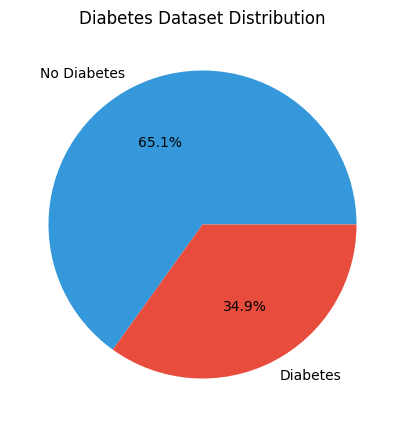

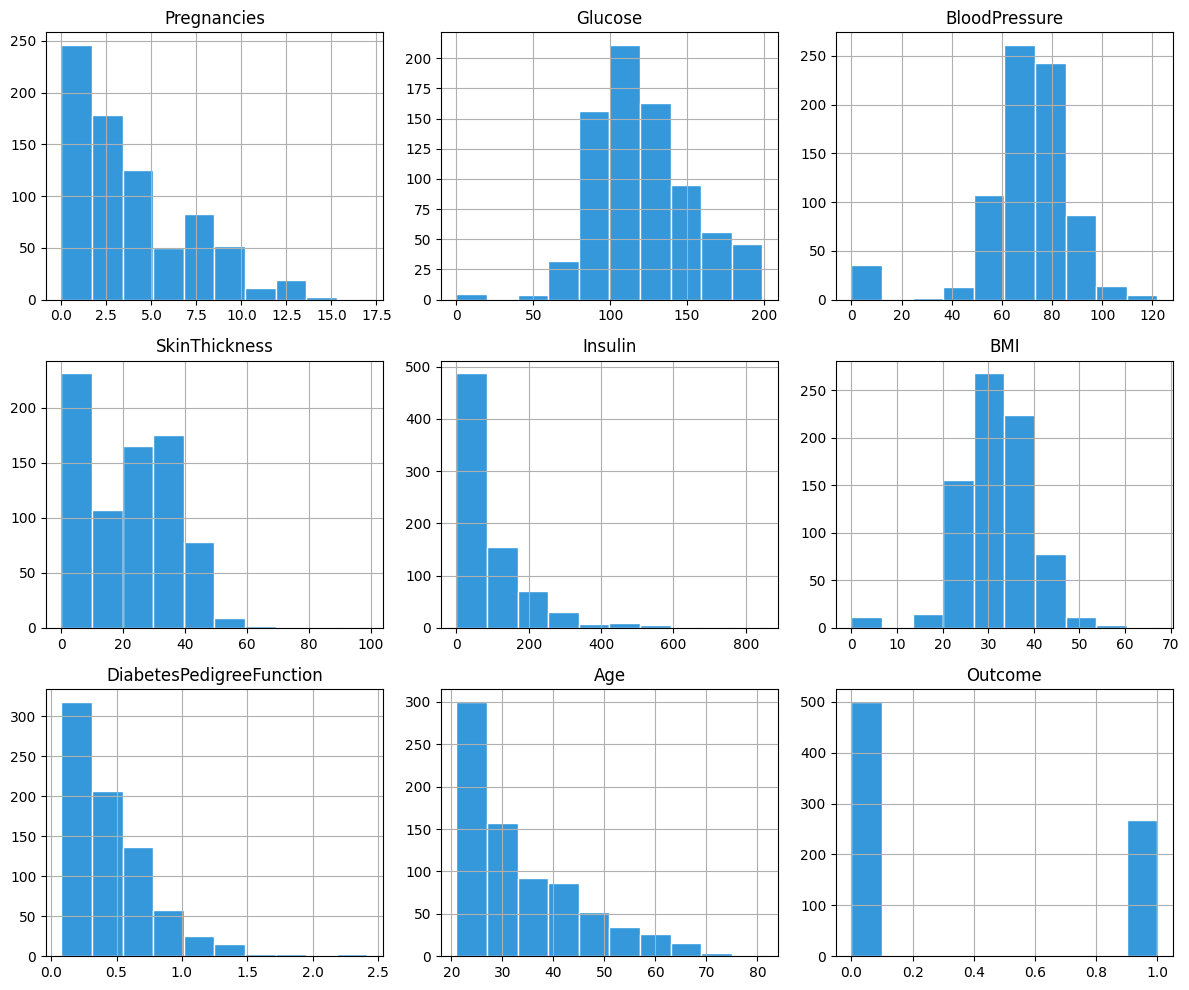

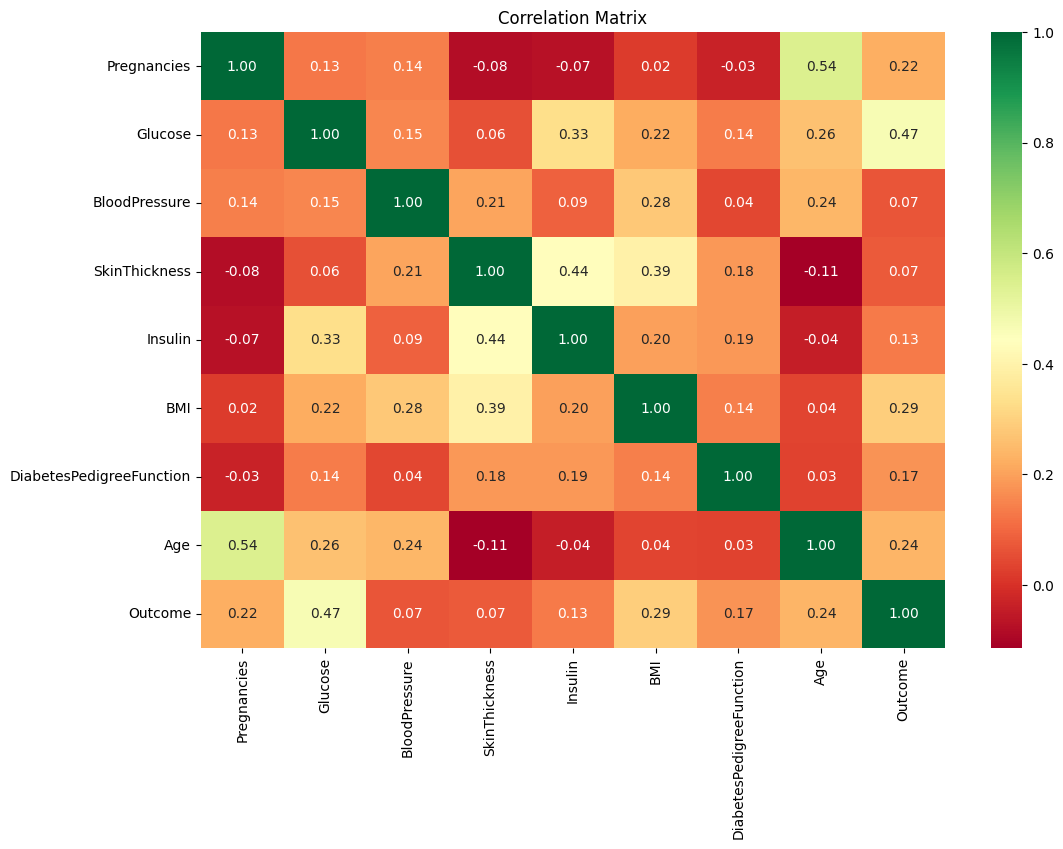

In [ ]:
plt.figure(figsize=(6,5))
data['Outcome'].value_counts().plot.pie(labels=['No Diabetes', 'Diabetes'], autopct='%1.1f%%', colors=['#3498db', '#e74c3c'])
plt.title('Diabetes Dataset Distribution')
plt.ylabel('')
plt.show()

data.hist(figsize=(12, 10), color='#3498db', edgecolor='white')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


We used the plotting libraries to generate three things:
First, a pie chart to visualize the percentage distribution of diabetic versus non-diabetic individuals in the dataset.
Second, histograms to examine the distribution of each feature or variable in the data individually.

In [ ]:
cols = ['Glucose', 'BloodPressure', 'BMI']
for col in cols:
    data[col] = data[col].replace(0, data[col].mean())

X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Preprocessing Completed")


Data Preprocessing Completed


here on the first code we played this code because the data has zeros in the value and that imposible because ther's not human on earth his value of insulin and othersis zero so the code takes the zero value and replace it with average of other number.
The code train test, split we split the value of the patient and make 80% of it to train it and get to use it
and 20% of the value to test it.
The scaler code makes the larger number almost even
so he don't ignore the small numbers because of the big one


Model Accuracy: 76.62 %


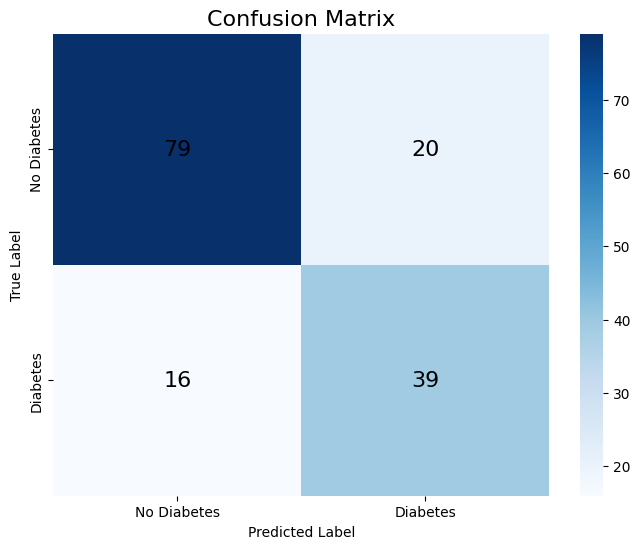

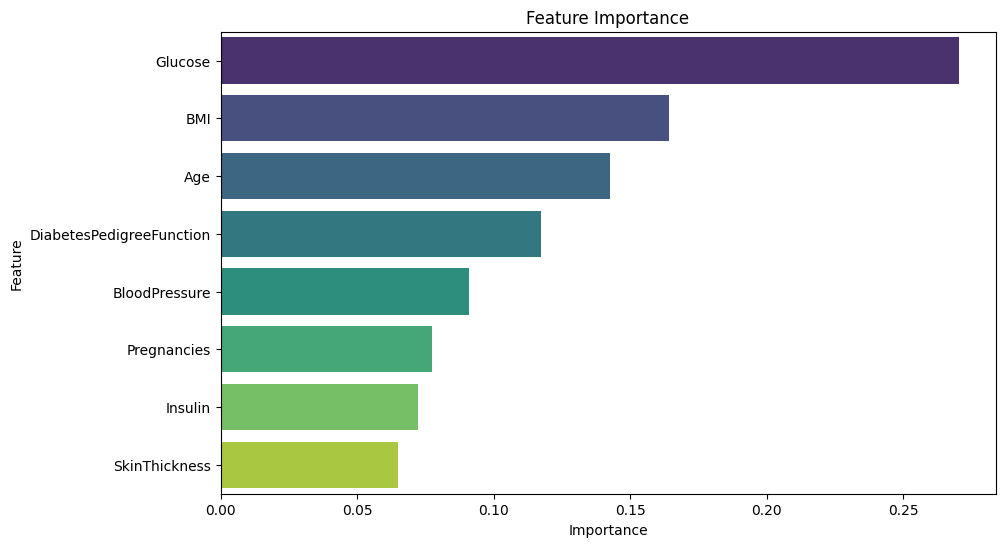

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16, "color": "black"},
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])

plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


features = X.columns
importances = model.feature_importances_
data_plot = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=data_plot, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance')
plt.show()


here the accuracy ratio is 76.62% and that mean that the system worke perfectly and strong and olso mean that his guesses was highly right.
and in the matrix code showed that from 154 patient tested the system guesses 79 healthy patient and the system guesses it right, 39 patience and the system guess it right, and 20 healthy patient and the system guess it wrong.the last figure code the system showed us that glucose the main factor in having diabetes and than BMI and so on

In [ ]:
import numpy as np
def glucosense_predict(data_input):
    data_input = np.array(data_input).reshape(1, -1)
    data_input = scaler.transform(data_input)
    probability = model.predict_proba(data_input)[0][1]

    print("\n--- GlucoSense Result ---")
    print(f"Risk Probability: {round(probability * 100, 2)}%")

    if probability > 0.7:
        print("RESULT: HIGH RISK")
    elif probability > 0.4:
        print("RESULT: MEDIUM RISK")
    else:
        print("RESULT: LOW RISK")

sample_data = [2, 140, 80, 25, 100, 32.5, 0.5, 45]
glucosense_predict(sample_data)


--- GlucoSense Result ---
Risk Probability: 72.0%
RESULT: HIGH RISK


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


This code represents the prediction part of the GlucoSense project. It takes the patient’s data and analyzes it using a pre-trained AI model to predict the probability of diabetes. First, we used the NumPy library to convert the data into a format suitable for the model. Then, we applied scaling to normalize the values and improve prediction accuracy. After that, we used the predict_proba function to calculate the probability of diabetes, and the result was displayed as a percentage. Based on the probability value, the system classifies the case as high risk, medium risk, or low risk. Finally, we tested the system using sample data to make sure the model works correctly and gives clear results to the user.

Conclusion
• Project Goal: GlucoSense successfully predicts diabetes risk using machine learning techniques.
• Best Model: The Random Forest algorithm achieved the highest accuracy and provided the most improved prediction performance.
• Impact: This system can be a valuable tool for early health monitoring and risk prevention.

Project Team Members:
• Renad Al-Talhabi
• Amal Salman
• Jumana Al-Dhafi

## 🔗 Project References
- https://github.com/Priyanshu88/Diabetes-Prediction  
- https://github.com/nicolelumagui/ML-Exercise_Pima-Indians-Diabetes_Classification  
- https://github.com/anandprakash0/Diabetes-prediction  
- https://github.com/omkarkshet/Diabetes-Prediction-Using-Machine-Learning-Techniques